This final model will combine the powerfull carbohydrate estimator model 24, with the ingredient estimator and mass estimator with a simple fusion head. To see if everything we can throw at the model can help it in improving over the current best model 22

Prerequisits

In [ ]:
!pip install -q keras-hub huggingface_hub scikit-learn joblib

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Avoid DINOv3/KerasHub XLA resize issues
tf.config.optimizer.set_jit(False)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

Mounted at /content/drive
TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Paths and settings

In [ ]:
# =========================================================
# MODEL 27
# Model 24 RDINet carb prediction
# + Model 18 mass feature/prediction
# + Model 20 ingredient feature/prediction
# + Model 21-style simple fusion head
# =========================================================

MODEL_NAME = "Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head"

MODEL27_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head"
)
MODEL27_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = MODEL27_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

# Model 24 RDINet prediction exports
MODEL24_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor"
)

MODEL24_VERIFIED_DIR = MODEL24_DIR / "verified_prediction_exports"

# Reuse same split files as Model 24 / Model 23
MODEL24_PREP_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_23_RDINet_3Level_DINOv2_RGB_DINOv2_depthcolor/prep_files"
)

train_csv = MODEL24_PREP_DIR / "train_model23.csv"
val_csv   = MODEL24_PREP_DIR / "val_model23.csv"
test_csv  = MODEL24_PREP_DIR / "test_model23.csv"

# Metadata with ingredient columns
INGREDIENT_METADATA_CSV = Path(
    "/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/"
    "dish_carb_mass_ingredients_split_metadata.csv"
)

# Model 18 mass estimator
MODEL18_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_18_DINOv3_RGB_only_Mass"
)

MODEL18_WEIGHTS = MODEL18_DIR / "best_model_stage2.weights.h5"
MODEL18_FINAL_MODEL = MODEL18_DIR / "final_model.keras"

# Model 20 ingredient estimator
MODEL20_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_20_DINOv2_base_ingredient_classifier"
)

MODEL20_WEIGHTS = MODEL20_DIR / "best_model_stage2.weights.h5"
MODEL20_FINAL_MODEL = MODEL20_DIR / "final_model.keras"

# Image settings
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

# Backbones, same as Model 21
MASS_BACKBONE_PRESET = "dinov3_vit_base_lvd1689m"
INGR_BACKBONE_PRESET = "dinov2_base"

# Combiner settings
COMBINER_EPOCHS = 500
COMBINER_LR = 1e-3
COMBINER_BATCH_SIZE = 16

print("Model 27 dir:", MODEL27_DIR)
print("Model 24 dir:", MODEL24_DIR)
print("Model 18 dir:", MODEL18_DIR)
print("Model 20 dir:", MODEL20_DIR)

Model 27 dir: /content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head
Model 24 dir: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor
Model 18 dir: /content/drive/MyDrive/Speciale/Models/Model_18_DINOv3_RGB_only_Mass
Model 20 dir: /content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier


Loading metadata

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

for d in [train_df, val_df, test_df]:
    d["dish_id"] = d["dish_id"].astype(str).str.strip()
    d["rgb_path"] = d["rgb_path"].astype(str)
    d["total_carb"] = pd.to_numeric(d["total_carb"], errors="coerce").astype("float32")

    if "depth_path" in d.columns:
        d["depth_path"] = d["depth_path"].astype(str)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

display(train_df.head())

Train: (2419, 10)
Val:   (334, 10)
Test:  (507, 10)


,dish_id,total_carb,split,source_cafe,rgb_path,depth_path,rgb_exists,depth_exists,rgb_size,depth_size
0,dish_1556572657,2.268,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,412129,128124
1,dish_1556573514,1.219,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,432908,286439
2,dish_1556575014,3.906,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,409854,300120
3,dish_1556575083,5.760,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,396942,288910
4,dish_1556575124,0.952,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,404314,287977


Loading ingredients

In [ ]:
ingredient_meta_df = pd.read_csv(INGREDIENT_METADATA_CSV)

ingredient_cols = [c for c in ingredient_meta_df.columns if c.startswith("ingr_")]

if len(ingredient_cols) == 0:
    raise ValueError("No ingredient columns found. Expected columns starting with 'ingr_'.")

NUM_INGREDIENTS = len(ingredient_cols)

print("Number of ingredient columns:", NUM_INGREDIENTS)
print("First 20 ingredient columns:")
print(ingredient_cols[:20])

Number of ingredient columns: 198
First 20 ingredient columns:
['ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy']


Loading saved model 24 predictions

In [ ]:
def find_model24_prediction_csv(split_name):
    search_dirs = []

    if MODEL24_VERIFIED_DIR.exists():
        search_dirs.append(MODEL24_VERIFIED_DIR)

    search_dirs.append(MODEL24_DIR)

    candidates = []

    for search_dir in search_dirs:
        for pattern in [
            f"*{split_name}*.csv",
            f"**/*{split_name}*.csv",
        ]:
            candidates.extend(list(search_dir.glob(pattern)))

    candidates = sorted(set(candidates))

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No Model 24 prediction CSV found for split '{split_name}'. "
            f"Searched in: {search_dirs}"
        )

    print(f"\nCandidate files for {split_name}:")
    for i, p in enumerate(candidates):
        print(i, p)

    preferred_keywords = [
        "verified",
        "rdinet",
        "prediction",
        "predictions",
        "export",
        split_name,
    ]

    bad_keywords = [
        "comparison",
        "summary",
        "metric",
        "model25",
        "model_25",
        "model26",
        "model_26",
        "model27",
        "model_27",
        "ingredient",
        "mass",
        "actual_mass",
    ]

    scored = []

    for p in candidates:
        name = p.name.lower()
        score = sum(k in name for k in preferred_keywords)
        score -= 10 * sum(k in name for k in bad_keywords)

        if "verified_prediction_exports" in str(p).lower():
            score += 5

        scored.append((score, p))

    scored = sorted(scored, key=lambda x: x[0], reverse=True)

    chosen = scored[0][1]
    print(f"Chosen {split_name} prediction CSV:", chosen)

    return chosen


def detect_prediction_column(df):
    preferred_cols = [
        "prediction",
        "pred",
        "y_pred",
        "rdinet_carb_pred",
        "model24_pred",
        "final_pred",
        "carb_pred",
        "predicted_carb",
        "carbohydrates_g",
    ]

    for col in preferred_cols:
        if col in df.columns:
            return col

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    pred_like_cols = [
        c for c in numeric_cols
        if "pred" in c.lower() or "prediction" in c.lower()
    ]

    if len(pred_like_cols) > 0:
        return pred_like_cols[0]

    raise ValueError(
        "Could not detect prediction column. Columns found:\n"
        + str(df.columns.tolist())
    )


def load_model24_predictions(split_name):
    csv_path = find_model24_prediction_csv(split_name)
    pred_df = pd.read_csv(csv_path)

    print(f"\nLoaded {split_name} prediction file:")
    print("Shape:", pred_df.shape)
    print("Columns:", pred_df.columns.tolist())

    if "dish_id" not in pred_df.columns:
        raise ValueError(f"'dish_id' missing in {csv_path}")

    pred_col = detect_prediction_column(pred_df)

    out = pred_df[["dish_id", pred_col]].copy()
    out = out.rename(columns={pred_col: "rdinet_carb_pred"})

    out["dish_id"] = out["dish_id"].astype(str).str.strip()
    out["rdinet_carb_pred"] = pd.to_numeric(
        out["rdinet_carb_pred"],
        errors="coerce"
    ).astype("float32")

    if out["rdinet_carb_pred"].isna().sum() > 0:
        raise ValueError(f"NaN values found in RDINet predictions for {split_name}")

    print("Using prediction column:", pred_col)
    display(out.head())

    return out


train_rdinet_pred_df = load_model24_predictions("train")
val_rdinet_pred_df   = load_model24_predictions("val")
test_rdinet_pred_df  = load_model24_predictions("test")


Candidate files for train:
0 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/model25_rdinet_predictions_train.csv
1 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_train_stage_1.csv
2 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_train_stage_2.csv
Chosen train prediction CSV: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_train_stage_1.csv

Loaded train prediction file:
Shape: (2419, 15)
Columns: ['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_path', 'depth_path', 'rgb_exists', 'depth_exists', 'rgb_size', 'depth_size', 'rdinet_carb_pred', 'rdinet_abs_error', 'rdinet_

,dish_id,rdinet_carb_pred
0,dish_1556572657,1.589515
1,dish_1556573514,2.321530
2,dish_1556575014,2.456608
3,dish_1556575083,3.129067
4,dish_1556575124,1.540793



Candidate files for val:
0 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/model25_rdinet_predictions_val.csv
1 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_1.csv
2 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_2.csv
Chosen val prediction CSV: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_1.csv

Loaded val prediction file:
Shape: (334, 15)
Columns: ['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_path', 'depth_path', 'rgb_exists', 'depth_exists', 'rgb_size', 'depth_size', 'rdinet_carb_pred', 'rdinet_abs_error', 'rdinet_signed_error', 

,dish_id,rdinet_carb_pred
0,dish_1559149615,0.494092
1,dish_1559149650,6.910615
2,dish_1559149688,0.720359
3,dish_1559149719,13.181520
4,dish_1559838214,0.896668



Candidate files for test:
0 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/model25_rdinet_predictions_test.csv
1 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_test_stage_1.csv
2 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_test_stage_2.csv
Chosen test prediction CSV: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_test_stage_1.csv

Loaded test prediction file:
Shape: (507, 15)
Columns: ['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_path', 'depth_path', 'rgb_exists', 'depth_exists', 'rgb_size', 'depth_size', 'rdinet_carb_pred', 'rdinet_abs_error', 'rdinet_signed_e

,dish_id,rdinet_carb_pred
0,dish_1556575327,11.217070
1,dish_1557861216,1.343749
2,dish_1557862345,1.691291
3,dish_1557862696,2.287569
4,dish_1557862738,2.843851


Merge predictions into splits

In [ ]:
def merge_rdinet_predictions(base_df, pred_df, split_name):
    base = base_df.copy()
    base["dish_id"] = base["dish_id"].astype(str).str.strip()

    pred = pred_df.copy()
    pred["dish_id"] = pred["dish_id"].astype(str).str.strip()

    merged = base.merge(
        pred,
        on="dish_id",
        how="left",
        validate="one_to_one"
    )

    missing = merged["rdinet_carb_pred"].isna().sum()
    print(f"{split_name} missing RDINet predictions:", missing)

    if missing > 0:
        display(merged[merged["rdinet_carb_pred"].isna()].head(20))
        raise ValueError(f"Missing RDINet predictions for {split_name}")

    return merged.reset_index(drop=True)


train_df = merge_rdinet_predictions(train_df, train_rdinet_pred_df, "train")
val_df   = merge_rdinet_predictions(val_df, val_rdinet_pred_df, "val")
test_df  = merge_rdinet_predictions(test_df, test_rdinet_pred_df, "test")

display(train_df[["dish_id", "total_carb", "rdinet_carb_pred"]].head())

train missing RDINet predictions: 0
val missing RDINet predictions: 0
test missing RDINet predictions: 0


,dish_id,total_carb,rdinet_carb_pred
0,dish_1556572657,2.268,1.589515
1,dish_1556573514,1.219,2.321530
2,dish_1556575014,3.906,2.456608
3,dish_1556575083,5.760,3.129067
4,dish_1556575124,0.952,1.540793


Metric function and baseline check

In [ ]:
def compute_pmae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = np.mean(np.abs(y_true - y_pred))
    mean_true = np.mean(y_true)

    return float(100.0 * mae / mean_true)


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    pmae = compute_pmae(y_true, y_pred)

    return {
        "mae": float(mae),
        "mse": float(mse),
        "rmse": float(rmse),
        "r2": float(r2),
        "pmae": float(pmae),
        "mean_true_carb": float(np.mean(y_true)),
    }


model24_train_metrics = compute_metrics(
    train_df["total_carb"],
    train_df["rdinet_carb_pred"]
)

model24_val_metrics = compute_metrics(
    val_df["total_carb"],
    val_df["rdinet_carb_pred"]
)

model24_test_metrics = compute_metrics(
    test_df["total_carb"],
    test_df["rdinet_carb_pred"]
)

print("Model 24 baseline train:", model24_train_metrics)
print("Model 24 baseline val:  ", model24_val_metrics)
print("Model 24 baseline test: ", model24_test_metrics)

Model 24 baseline train: {'mae': 1.725771427154541, 'mse': 11.46976375579834, 'rmse': 3.3867039663658733, 'r2': 0.978520929813385, 'pmae': 8.88852596282959, 'mean_true_carb': 19.415721893310547}
Model 24 baseline val:   {'mae': 4.404017925262451, 'mse': 38.88702392578125, 'rmse': 6.235946113123593, 'r2': 0.8292625546455383, 'pmae': 23.430158615112305, 'mean_true_carb': 18.796363830566406}
Model 24 baseline test:  {'mae': 4.719059467315674, 'mse': 53.89215850830078, 'rmse': 7.34112787712493, 'r2': 0.8224477171897888, 'pmae': 23.974580764770508, 'mean_true_carb': 19.683595657348633}


Image dataset loading for mass and ingredient estimator models

In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_for_prediction(rgb_path):
    rgb = load_rgb_image(rgb_path)
    return {"rgb_input": rgb}


def make_rgb_prediction_dataset(dataframe, batch_size=BATCH_SIZE):
    rgb_paths = dataframe["rgb_path"].astype(str).values

    ds = tf.data.Dataset.from_tensor_slices(rgb_paths)
    ds = ds.map(load_rgb_for_prediction, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_rgb_dataset = make_rgb_prediction_dataset(train_df, batch_size=BATCH_SIZE)
val_rgb_dataset   = make_rgb_prediction_dataset(val_df, batch_size=BATCH_SIZE)
test_rgb_dataset  = make_rgb_prediction_dataset(test_df, batch_size=BATCH_SIZE)

for batch_inputs in train_rgb_dataset.take(1):
    print("Input keys:", batch_inputs.keys())
    print("RGB shape:", batch_inputs["rgb_input"].shape)

Input keys: dict_keys(['rgb_input'])
RGB shape: (16, 224, 224, 3)


In [ ]:
def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "encoded_tokens",
            "last_hidden_state",
            "pooled_output",
        ]

        for key in preferred_keys:
            if key in x:
                return x[key]

        return list(x.values())[0]

    return x

Building model 18 mass estimator

In [ ]:
def build_model18_mass_branch():
    rgb_input = keras.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        name="rgb_input"
    )

    image_converter = keras_hub.layers.ImageConverter.from_preset(
        MASS_BACKBONE_PRESET,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
    )

    backbone = keras_hub.models.Backbone.from_preset(
        MASS_BACKBONE_PRESET,
        image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )

    backbone.trainable = False

    x = image_converter(rgb_input)
    x = backbone(x)
    x = extract_backbone_tensor(x)

    if len(x.shape) == 3:
        x = layers.LayerNormalization(name="mass_ln")(x)
        x = layers.GlobalAveragePooling1D(name="mass_token_pool")(x)
    else:
        x = layers.LayerNormalization(name="mass_ln")(x)
        x = layers.Flatten(name="mass_flatten")(x)

    x = layers.Dropout(0.3, name="mass_dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="mass_dense_256")(x)
    x = layers.Dropout(0.3, name="mass_dropout_2")(x)

    feat = layers.Dense(64, activation="relu", name="mass_dense_64")(x)

    output = layers.Dense(
        1,
        activation="linear",
        name="mass_output"
    )(feat)

    model = keras.Model(
        inputs={"rgb_input": rgb_input},
        outputs=output,
        name="model18_mass_branch"
    )

    return model

Model 20 ingredient estimator

In [ ]:
def build_model20_ingredient_branch(num_ingredients):
    rgb_input = keras.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        name="rgb_input"
    )

    image_converter = keras_hub.layers.ImageConverter.from_preset(
        INGR_BACKBONE_PRESET,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
    )

    backbone = keras_hub.models.Backbone.from_preset(
        INGR_BACKBONE_PRESET,
        image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    )

    backbone.trainable = False

    x = image_converter(rgb_input)
    x = backbone(x)
    x = extract_backbone_tensor(x)

    if len(x.shape) == 3:
        x = layers.LayerNormalization(name="ingr_ln")(x)
        x = layers.GlobalAveragePooling1D(name="ingr_token_pool")(x)
    else:
        x = layers.LayerNormalization(name="ingr_ln")(x)
        x = layers.Flatten(name="ingr_flatten")(x)

    x = layers.Dropout(0.3, name="ingr_dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="ingr_dense_256")(x)
    x = layers.Dropout(0.3, name="ingr_dropout_2")(x)

    feat = layers.Dense(
        128,
        activation="relu",
        name="ingr_dense_128"
    )(x)

    x = layers.Dropout(0.2, name="ingr_dropout_3")(feat)

    output = layers.Dense(
        num_ingredients,
        activation="sigmoid",
        name="ingredient_output"
    )(x)

    model = keras.Model(
        inputs={"rgb_input": rgb_input},
        outputs=output,
        name="model20_ingredient_branch"
    )

    return model

Loading model 18 and model 20 weights

In [ ]:
mass_branch_model = build_model18_mass_branch()
ingredient_branch_model = build_model20_ingredient_branch(NUM_INGREDIENTS)

if not MODEL18_WEIGHTS.exists():
    raise FileNotFoundError(f"Could not find Model 18 weights: {MODEL18_WEIGHTS}")

if not MODEL20_WEIGHTS.exists():
    raise FileNotFoundError(f"Could not find Model 20 weights: {MODEL20_WEIGHTS}")

mass_branch_model.load_weights(str(MODEL18_WEIGHTS))
ingredient_branch_model.load_weights(str(MODEL20_WEIGHTS))

print("Loaded Model 18 mass weights.")
print("Loaded Model 20 ingredient weights.")

100%|██████████| 1.13k/1.13k [00:00<00:00, 2.54MB/s]


100%|██████████| 978/978 [00:00<00:00, 635kB/s]


100%|██████████| 327M/327M [00:08<00:00, 42.4MB/s]


100%|██████████| 781/781 [00:00<00:00, 2.23MB/s]


100%|██████████| 977/977 [00:00<00:00, 2.48MB/s]


100%|██████████| 335M/335M [00:07<00:00, 49.2MB/s]


Loaded Model 18 mass weights.
Loaded Model 20 ingredient weights.


Feature extraction models

In [ ]:
mass_feature_model = keras.Model(
    inputs=mass_branch_model.input,
    outputs=[
        mass_branch_model.get_layer("mass_dense_64").output,
        mass_branch_model.output
    ],
    name="mass_feature_model"
)

ingredient_feature_model = keras.Model(
    inputs=ingredient_branch_model.input,
    outputs=[
        ingredient_branch_model.get_layer("ingr_dense_128").output,
        ingredient_branch_model.output
    ],
    name="ingredient_feature_model"
)

mass_feature_model.trainable = False
ingredient_feature_model.trainable = False

# Avoid XLA prediction issue
try:
    mass_feature_model.jit_compile = False
    ingredient_feature_model.jit_compile = False
except Exception as e:
    print("Could not directly set jit_compile:", e)

mass_feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="mse",
    jit_compile=False
)

ingredient_feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    jit_compile=False
)

print("Mass feature model:")
mass_feature_model.summary()

print("Ingredient feature model:")
ingredient_feature_model.summary()

Mass feature model:


Model: "mass_feature_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov3_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV3ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov3_backbone                 │ (None, 201, 768)       │    85,660,416 │
│ (DINOV3Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mass_ln (LayerNormalization)    │ (None, 201, 768)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mass_token_pool                 │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mass_dropout_1 (Dropout)        │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mass_dense_256 (Dense)          │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mass_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mass_dense_64 (Dense)           │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mass_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,875,329 (327.59 MB)

 Trainable params: 0 (0.00 B)

...

Model: "ingredient_feature_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 768)       │    86,777,856 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingr_ln (LayerNormalization)    │ (None, 257, 768)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingr_token_pool                 │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingr_dropout_1 (Dropout)        │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingr_dense_256 (Dense)          │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingr_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingr_dense_128 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingr_dropout_3 (Dropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingredient_output (Dense)       │ (None, 198)            │        25,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,034,694 (332.01 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 87,034,694 (332.01 MB)

In [ ]:
from tqdm.auto import tqdm

def predict_feature_model_eager(model, dataset, desc="Predicting"):
    features = []
    preds = []

    for batch in tqdm(dataset, desc=desc):
        batch_feat, batch_pred = model(batch, training=False)

        features.append(batch_feat.numpy())
        preds.append(batch_pred.numpy())

    features = np.concatenate(features, axis=0)
    preds = np.concatenate(preds, axis=0)

    return features, preds

Generating mass predictions

In [ ]:
train_mass_feat, train_mass_pred = predict_feature_model_eager(
    mass_feature_model,
    train_rgb_dataset,
    desc="Mass train"
)

val_mass_feat, val_mass_pred = predict_feature_model_eager(
    mass_feature_model,
    val_rgb_dataset,
    desc="Mass val"
)

test_mass_feat, test_mass_pred = predict_feature_model_eager(
    mass_feature_model,
    test_rgb_dataset,
    desc="Mass test"
)

train_mass_pred = train_mass_pred.reshape(-1, 1)
val_mass_pred   = val_mass_pred.reshape(-1, 1)
test_mass_pred  = test_mass_pred.reshape(-1, 1)

print("train_mass_feat:", train_mass_feat.shape)
print("train_mass_pred:", train_mass_pred.shape)
print("val_mass_feat:", val_mass_feat.shape)
print("val_mass_pred:", val_mass_pred.shape)
print("test_mass_feat:", test_mass_feat.shape)
print("test_mass_pred:", test_mass_pred.shape)

Mass train:   0%|          | 0/152 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(3, 224, 224, 3))
  warnings.warn(msg)


Mass val:   0%|          | 0/21 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(14, 224, 224, 3))
  warnings.warn(msg)


Mass test:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(11, 224, 224, 3))
  warnings.warn(msg)


train_mass_feat: (2419, 64)
train_mass_pred: (2419, 1)
val_mass_feat: (334, 64)
val_mass_pred: (334, 1)
test_mass_feat: (507, 64)
test_mass_pred: (507, 1)


Generating ingredient predictions

In [ ]:
train_ingr_feat, train_ingr_pred = predict_feature_model_eager(
    ingredient_feature_model,
    train_rgb_dataset,
    desc="Ingredients train"
)

val_ingr_feat, val_ingr_pred = predict_feature_model_eager(
    ingredient_feature_model,
    val_rgb_dataset,
    desc="Ingredients val"
)

test_ingr_feat, test_ingr_pred = predict_feature_model_eager(
    ingredient_feature_model,
    test_rgb_dataset,
    desc="Ingredients test"
)

print("train_ingr_feat:", train_ingr_feat.shape)
print("train_ingr_pred:", train_ingr_pred.shape)
print("val_ingr_feat:", val_ingr_feat.shape)
print("val_ingr_pred:", val_ingr_pred.shape)
print("test_ingr_feat:", test_ingr_feat.shape)
print("test_ingr_pred:", test_ingr_pred.shape)

if train_ingr_pred.shape[1] != NUM_INGREDIENTS:
    raise ValueError(
        f"Ingredient output mismatch. Got {train_ingr_pred.shape[1]}, "
        f"expected {NUM_INGREDIENTS}."
    )

Ingredients train:   0%|          | 0/152 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(3, 224, 224, 3))
  warnings.warn(msg)


Ingredients val:   0%|          | 0/21 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(14, 224, 224, 3))
  warnings.warn(msg)


Ingredients test:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(11, 224, 224, 3))
  warnings.warn(msg)


train_ingr_feat: (2419, 128)
train_ingr_pred: (2419, 198)
val_ingr_feat: (334, 128)
val_ingr_pred: (334, 198)
test_ingr_feat: (507, 128)
test_ingr_pred: (507, 198)


Building and saving combiner features

In [ ]:
mass_feat_cols = [f"mass_feat_{i}" for i in range(train_mass_feat.shape[1])]
ingr_feat_cols = [f"ingr_feat_{i}" for i in range(train_ingr_feat.shape[1])]
pred_ingredient_cols = [f"pred_{col}" for col in ingredient_cols]


def build_combiner_df(base_df, mass_feat, mass_pred, ingr_feat, ingr_pred):
    out = base_df[["dish_id", "total_carb", "split", "rdinet_carb_pred"]].copy()

    if "source_cafe" in base_df.columns:
        out["source_cafe"] = base_df["source_cafe"].values

    out["predicted_mass"] = mass_pred.reshape(-1).astype("float32")

    mass_feat_df = pd.DataFrame(
        mass_feat.astype("float32"),
        columns=mass_feat_cols
    )

    ingr_feat_df = pd.DataFrame(
        ingr_feat.astype("float32"),
        columns=ingr_feat_cols
    )

    ingr_pred_df = pd.DataFrame(
        ingr_pred.astype("float32"),
        columns=pred_ingredient_cols
    )

    out = pd.concat(
        [
            out.reset_index(drop=True),
            mass_feat_df.reset_index(drop=True),
            ingr_feat_df.reset_index(drop=True),
            ingr_pred_df.reset_index(drop=True),
        ],
        axis=1
    )

    return out


train_combiner_df = build_combiner_df(
    train_df,
    train_mass_feat,
    train_mass_pred,
    train_ingr_feat,
    train_ingr_pred
)

val_combiner_df = build_combiner_df(
    val_df,
    val_mass_feat,
    val_mass_pred,
    val_ingr_feat,
    val_ingr_pred
)

test_combiner_df = build_combiner_df(
    test_df,
    test_mass_feat,
    test_mass_pred,
    test_ingr_feat,
    test_ingr_pred
)

train_combiner_csv = PREP_DIR / "train_model27_combiner_features.csv"
val_combiner_csv   = PREP_DIR / "val_model27_combiner_features.csv"
test_combiner_csv  = PREP_DIR / "test_model27_combiner_features.csv"

train_combiner_df.to_csv(train_combiner_csv, index=False)
val_combiner_df.to_csv(val_combiner_csv, index=False)
test_combiner_df.to_csv(test_combiner_csv, index=False)

print("Saved:")
print(train_combiner_csv)
print(val_combiner_csv)
print(test_combiner_csv)

display(train_combiner_df.head())

Saved:
/content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/prep_files/train_model27_combiner_features.csv
/content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/prep_files/val_model27_combiner_features.csv
/content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/prep_files/test_model27_combiner_features.csv


,dish_id,total_carb,split,rdinet_carb_pred,source_cafe,predicted_mass,mass_feat_0,mass_feat_1,mass_feat_2,mass_feat_3,...,pred_ingr_wheat_berry,pred_ingr_wheat_bread,pred_ingr_white_beans,pred_ingr_white_rice,pred_ingr_white_wine,pred_ingr_wild_rice,pred_ingr_wine,pred_ingr_yam,pred_ingr_yogurt,pred_ingr_zucchini
0,dish_1556572657,2.268,train,1.589515,cafe1,30.095984,0.491310,0.558501,0.0,0.0,...,1.366461e-07,1.952989e-08,2.519240e-12,2.138126e-07,2.997105e-11,2.286769e-13,1.978381e-09,2.971376e-08,1.988418e-06,0.000002
1,dish_1556573514,1.219,train,2.321530,cafe1,25.210068,0.297822,0.481571,0.0,0.0,...,8.600344e-05,7.758268e-06,3.372057e-06,1.698733e-05,2.777317e-07,4.196183e-08,3.065887e-04,4.087855e-05,1.062072e-03,0.000753
2,dish_1556575014,3.906,train,2.456608,cafe1,53.147095,0.000000,0.485440,0.0,0.0,...,9.413841e-07,9.767211e-09,2.003059e-11,8.791350e-07,2.489921e-10,1.605192e-12,1.032263e-08,5.114266e-08,9.578270e-07,0.000005
3,dish_1556575083,5.760,train,3.129067,cafe1,63.532745,0.000000,0.274683,0.0,0.0,...,3.201231e-06,8.337843e-10,2.432278e-11,9.107604e-07,5.040658e-11,9.297707e-13,3.563266e-07,2.200900e-05,5.886317e-08,0.000004
4,dish_1556575124,0.952,train,1.540793,cafe1,23.535311,0.468061,0.558720,0.0,0.0,...,6.443356e-06,1.591482e-06,1.059011e-06,1.114444e-05,7.392039e-09,4.204815e-10,2.756775e-05,3.691524e-05,4.968416e-05,0.000944


Model 27 input arrays

In [ ]:
# Model 24 prediction
X_train_rdinet = train_combiner_df[["rdinet_carb_pred"]].values.astype("float32")
X_val_rdinet   = val_combiner_df[["rdinet_carb_pred"]].values.astype("float32")
X_test_rdinet  = test_combiner_df[["rdinet_carb_pred"]].values.astype("float32")

# Model 18 mass feature and prediction
X_train_mass_feat = train_combiner_df[mass_feat_cols].values.astype("float32")
X_val_mass_feat   = val_combiner_df[mass_feat_cols].values.astype("float32")
X_test_mass_feat  = test_combiner_df[mass_feat_cols].values.astype("float32")

X_train_mass_pred = train_combiner_df[["predicted_mass"]].values.astype("float32")
X_val_mass_pred   = val_combiner_df[["predicted_mass"]].values.astype("float32")
X_test_mass_pred  = test_combiner_df[["predicted_mass"]].values.astype("float32")

# Model 20 ingredient feature and prediction
X_train_ingr_feat = train_combiner_df[ingr_feat_cols].values.astype("float32")
X_val_ingr_feat   = val_combiner_df[ingr_feat_cols].values.astype("float32")
X_test_ingr_feat  = test_combiner_df[ingr_feat_cols].values.astype("float32")

X_train_ingr_pred = train_combiner_df[pred_ingredient_cols].values.astype("float32")
X_val_ingr_pred   = val_combiner_df[pred_ingredient_cols].values.astype("float32")
X_test_ingr_pred  = test_combiner_df[pred_ingredient_cols].values.astype("float32")

# Target
y_train = train_combiner_df["total_carb"].values.astype("float32")
y_val   = val_combiner_df["total_carb"].values.astype("float32")
y_test  = test_combiner_df["total_carb"].values.astype("float32")

print("X_train_rdinet:", X_train_rdinet.shape)
print("X_train_mass_feat:", X_train_mass_feat.shape)
print("X_train_mass_pred:", X_train_mass_pred.shape)
print("X_train_ingr_feat:", X_train_ingr_feat.shape)
print("X_train_ingr_pred:", X_train_ingr_pred.shape)
print("y_train:", y_train.shape)

X_train_rdinet: (2419, 1)
X_train_mass_feat: (2419, 64)
X_train_mass_pred: (2419, 1)
X_train_ingr_feat: (2419, 128)
X_train_ingr_pred: (2419, 198)
y_train: (2419,)


In [ ]:
rdinet_scaler = StandardScaler()
mass_feat_scaler = StandardScaler()
mass_pred_scaler = StandardScaler()
ingr_feat_scaler = StandardScaler()

X_train_rdinet_scaled = rdinet_scaler.fit_transform(X_train_rdinet).astype("float32")
X_val_rdinet_scaled   = rdinet_scaler.transform(X_val_rdinet).astype("float32")
X_test_rdinet_scaled  = rdinet_scaler.transform(X_test_rdinet).astype("float32")

X_train_mass_feat_scaled = mass_feat_scaler.fit_transform(X_train_mass_feat).astype("float32")
X_val_mass_feat_scaled   = mass_feat_scaler.transform(X_val_mass_feat).astype("float32")
X_test_mass_feat_scaled  = mass_feat_scaler.transform(X_test_mass_feat).astype("float32")

X_train_mass_pred_scaled = mass_pred_scaler.fit_transform(X_train_mass_pred).astype("float32")
X_val_mass_pred_scaled   = mass_pred_scaler.transform(X_val_mass_pred).astype("float32")
X_test_mass_pred_scaled  = mass_pred_scaler.transform(X_test_mass_pred).astype("float32")

X_train_ingr_feat_scaled = ingr_feat_scaler.fit_transform(X_train_ingr_feat).astype("float32")
X_val_ingr_feat_scaled   = ingr_feat_scaler.transform(X_val_ingr_feat).astype("float32")
X_test_ingr_feat_scaled  = ingr_feat_scaler.transform(X_test_ingr_feat).astype("float32")

scalers = {
    "rdinet_scaler": rdinet_scaler,
    "mass_feat_scaler": mass_feat_scaler,
    "mass_pred_scaler": mass_pred_scaler,
    "ingr_feat_scaler": ingr_feat_scaler,
}

scaler_path = MODEL27_DIR / "model27_feature_scalers.joblib"
joblib.dump(scalers, scaler_path)

print("Saved scalers to:", scaler_path)

Saved scalers to: /content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/model27_feature_scalers.joblib


In [ ]:
X_train = np.concatenate(
    [
        X_train_rdinet_scaled,
        X_train_mass_feat_scaled,
        X_train_mass_pred_scaled,
        X_train_ingr_feat_scaled,
        X_train_ingr_pred,
    ],
    axis=1
).astype("float32")

X_val = np.concatenate(
    [
        X_val_rdinet_scaled,
        X_val_mass_feat_scaled,
        X_val_mass_pred_scaled,
        X_val_ingr_feat_scaled,
        X_val_ingr_pred,
    ],
    axis=1
).astype("float32")

X_test = np.concatenate(
    [
        X_test_rdinet_scaled,
        X_test_mass_feat_scaled,
        X_test_mass_pred_scaled,
        X_test_ingr_feat_scaled,
        X_test_ingr_pred,
    ],
    axis=1
).astype("float32")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (2419, 392)
X_val: (334, 392)
X_test: (507, 392)


Model 27 fusion head

In [ ]:
tf.keras.backend.clear_session()

fusion_input = keras.Input(
    shape=(X_train.shape[1],),
    name="model27_fusion_input"
)

fusion = layers.Dense(
    256,
    activation="relu",
    name="fusion_dense_256"
)(fusion_input)

fusion = layers.Dropout(
    0.35,
    name="fusion_dropout_1"
)(fusion)

fusion = layers.Dense(
    128,
    activation="relu",
    name="fusion_dense_128"
)(fusion)

fusion = layers.Dropout(
    0.25,
    name="fusion_dropout_2"
)(fusion)

fusion = layers.Dense(
    64,
    activation="relu",
    name="fusion_dense_64"
)(fusion)

fusion = layers.Dropout(
    0.15,
    name="fusion_dropout_3"
)(fusion)

carb_output = layers.Dense(
    1,
    activation="linear",
    name="carb_output"
)(fusion)

model27 = keras.Model(
    inputs=fusion_input,
    outputs=carb_output,
    name="model_27_rdinet_mass_ingredient_fusion"
)

model27.compile(
    optimizer=keras.optimizers.Adam(learning_rate=COMBINER_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse"),
    ]
)

model27.summary()

Model: "model_27_rdinet_mass_ingredient_fusion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ model27_fusion_input            │ (None, 392)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dense_256 (Dense)        │ (None, 256)            │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dropout_1 (Dropout)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dense_128 (Dense)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dropout_2 (Dropout)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dense_64 (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fusion_dropout_3 (Dropout)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,825 (554.00 KB)

 Trainable params: 141,825 (554.00 KB)

 Non-trainable params: 0 (0.00 B)

Training model 27

In [ ]:
model27_best_path = MODEL27_DIR / "best_model27_rdinet_mass_ingredient_fusion.weights.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(model27_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=200,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=150,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

history_model27 = model27.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=COMBINER_EPOCHS,
    batch_size=COMBINER_BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/500
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 388.5381 - mae: 11.9303 - mse: 388.5381
Epoch 1: val_loss improved from None to 55.85418, saving model to /content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/best_model27_rdinet_mass_ingredient_fusion.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/best_model27_rdinet_mass_ingredient_fusion.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - loss: 303.4295 - mae: 8.8483 - mse: 303.4295 - val_loss: 55.8542 - val_mae: 5.7376 - val_mse: 55.8542 - learning_rate: 0.0010
Epoch 2/500
139/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 139.6938 - mae: 5.9160 - mse: 139.6938
Epoch 2: val_loss improved from 55.85418 to 48.07391, saving model to /content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/best_model27_rdinet_mass_ingredient_fusion.weights.h

Plotting training and validation curves

Loaded best Model 27 weights from: /content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/best_model27_rdinet_mass_ingredient_fusion.weights.h5


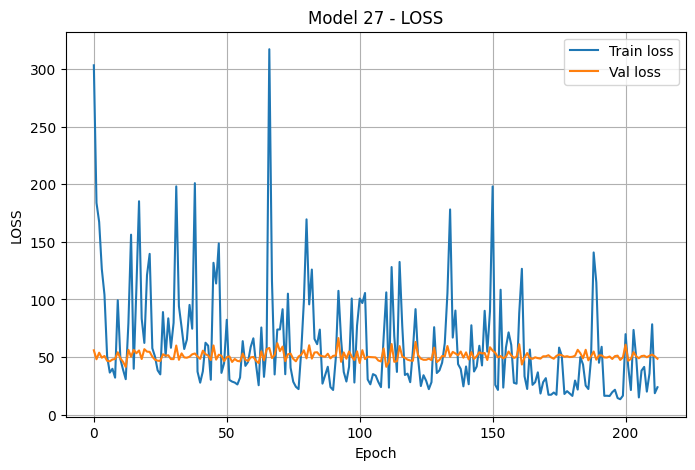

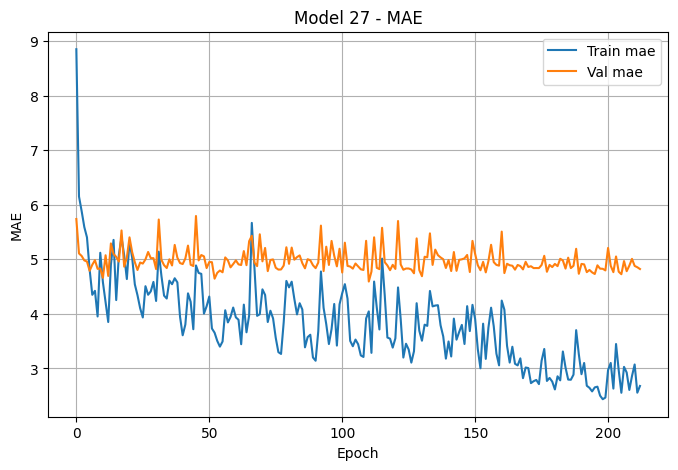

In [ ]:
model27.load_weights(str(model27_best_path))
print("Loaded best Model 27 weights from:", model27_best_path)

for metric in ["loss", "mae"]:
    plt.figure(figsize=(8, 5))
    plt.plot(history_model27.history[metric], label=f"Train {metric}")
    plt.plot(history_model27.history[f"val_{metric}"], label=f"Val {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.title(f"Model 27 - {metric.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()

Prediction with model 27

In [ ]:
train_model27_preds = model27.predict(X_train, verbose=1).reshape(-1)
val_model27_preds   = model27.predict(X_val, verbose=1).reshape(-1)
test_model27_preds  = model27.predict(X_test, verbose=1).reshape(-1)

print("Train preds:", train_model27_preds.shape)
print("Val preds:  ", val_model27_preds.shape)
print("Test preds: ", test_model27_preds.shape)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Train preds: (2419,)
Val preds:   (334,)
Test preds:  (507,)


Comparing results

In [ ]:
def build_metric_row(model_name, y_train, train_pred, y_val, val_pred, y_test, test_pred):
    train_metrics = compute_metrics(y_train, train_pred)
    val_metrics   = compute_metrics(y_val, val_pred)
    test_metrics  = compute_metrics(y_test, test_pred)

    return {
        "model": model_name,

        "train_mae": train_metrics["mae"],
        "train_mse": train_metrics["mse"],
        "train_rmse": train_metrics["rmse"],
        "train_r2": train_metrics["r2"],
        "train_pmae": train_metrics["pmae"],

        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
        "val_rmse": val_metrics["rmse"],
        "val_r2": val_metrics["r2"],
        "val_pmae": val_metrics["pmae"],

        "test_mae": test_metrics["mae"],
        "test_mse": test_metrics["mse"],
        "test_rmse": test_metrics["rmse"],
        "test_r2": test_metrics["r2"],
        "test_pmae": test_metrics["pmae"],
    }


results = []

results.append(build_metric_row(
    "Model_24_RDINet_RGBD_baseline",
    y_train, train_combiner_df["rdinet_carb_pred"].values,
    y_val,   val_combiner_df["rdinet_carb_pred"].values,
    y_test,  test_combiner_df["rdinet_carb_pred"].values,
))

results.append(build_metric_row(
    "Model_27_RDINet_plus_mass_and_ingredients_Model21_head",
    y_train, train_model27_preds,
    y_val,   val_model27_preds,
    y_test,  test_model27_preds,
))

results_df = pd.DataFrame(results).sort_values(
    "val_mse",
    ascending=True
).reset_index(drop=True)

display(results_df)

results_csv = MODEL27_DIR / "model27_comparison_rdinet_vs_rdinet_mass_ingredients.csv"
results_df.to_csv(results_csv, index=False)

print("Saved results to:", results_csv)

,model,train_mae,train_mse,train_rmse,train_r2,train_pmae,val_mae,val_mse,val_rmse,val_r2,val_pmae,test_mae,test_mse,test_rmse,test_r2,test_pmae
0,Model_24_RDINet_RGBD_baseline,1.725771,11.469764,3.386704,0.978521,8.888526,4.404018,38.887024,6.235946,0.829263,23.430159,4.719059,53.892159,7.341128,0.822448,23.974581
1,Model_27_RDINet_plus_mass_and_ingredients_Mode...,2.459477,23.905485,4.889324,0.955233,12.667450,4.695036,41.387993,6.433350,0.818282,24.978428,5.124676,58.736553,7.663978,0.806487,26.035267


Saved results to: /content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/model27_comparison_rdinet_vs_rdinet_mass_ingredients.csv


Saving final model

In [ ]:
final_model_path = MODEL27_DIR / "model27_rdinet_mass_ingredient_fusion.keras"
model27.save(final_model_path)

print("Saved final Model 27 combiner to:", final_model_path)

Saved final Model 27 combiner to: /content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/model27_rdinet_mass_ingredient_fusion.keras


Saving predictions

In [ ]:
train_results_df = train_combiner_df.copy()
val_results_df   = val_combiner_df.copy()
test_results_df  = test_combiner_df.copy()

train_results_df["model27_pred"] = train_model27_preds
val_results_df["model27_pred"]   = val_model27_preds
test_results_df["model27_pred"]  = test_model27_preds

for df_out in [train_results_df, val_results_df, test_results_df]:
    df_out["model24_abs_error"] = np.abs(
        df_out["total_carb"].values - df_out["rdinet_carb_pred"].values
    )

    df_out["model27_abs_error"] = np.abs(
        df_out["total_carb"].values - df_out["model27_pred"].values
    )

    df_out["model27_signed_error"] = (
        df_out["model27_pred"].values - df_out["total_carb"].values
    )

train_predictions_csv = MODEL27_DIR / "model27_train_predictions.csv"
val_predictions_csv   = MODEL27_DIR / "model27_val_predictions.csv"
test_predictions_csv  = MODEL27_DIR / "model27_test_predictions.csv"

train_results_df.to_csv(train_predictions_csv, index=False)
val_results_df.to_csv(val_predictions_csv, index=False)
test_results_df.to_csv(test_predictions_csv, index=False)

print("Saved predictions:")
print(train_predictions_csv)
print(val_predictions_csv)
print(test_predictions_csv)

display(test_results_df.head())

Saved predictions:
/content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/model27_train_predictions.csv
/content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/model27_val_predictions.csv
/content/drive/MyDrive/Speciale/Models/Model_27_RDINet_RGBD_plus_mass_and_ingredients_Model21_head/model27_test_predictions.csv


,dish_id,total_carb,split,rdinet_carb_pred,source_cafe,predicted_mass,mass_feat_0,mass_feat_1,mass_feat_2,mass_feat_3,...,pred_ingr_white_wine,pred_ingr_wild_rice,pred_ingr_wine,pred_ingr_yam,pred_ingr_yogurt,pred_ingr_zucchini,model27_pred,model24_abs_error,model27_abs_error,model27_signed_error
0,dish_1556575327,10.618,test,11.217070,cafe1,157.546173,0.207217,0.000000,0.0,0.0,...,3.224985e-09,7.206558e-10,6.879267e-07,0.000013,1.457743e-07,0.000081,12.639510,0.599070,2.021510,2.021510
1,dish_1557861216,0.000,test,1.343749,cafe1,23.702986,0.641202,0.404906,0.0,0.0,...,4.800548e-10,2.152842e-10,1.531191e-06,0.000007,3.537523e-04,0.000136,1.726654,1.343749,1.726654,1.726654
2,dish_1557862345,0.000,test,1.691291,cafe1,47.359634,0.320944,0.429444,0.0,0.0,...,9.985084e-07,1.876712e-10,4.616476e-06,0.000087,1.361913e-03,0.000048,1.334475,1.691291,1.334475,1.334475
3,dish_1557862696,3.850,test,2.287569,cafe1,67.079849,0.192879,0.267278,0.0,0.0,...,1.297776e-09,1.728307e-11,9.407367e-06,0.000038,3.801858e-03,0.000005,2.129274,1.562431,1.720726,-1.720726
4,dish_1557862738,0.000,test,2.843851,cafe1,98.336594,0.000000,0.000000,0.0,0.0,...,3.225133e-06,2.230707e-07,2.087009e-04,0.003102,7.736103e-06,0.001087,3.347097,2.843851,3.347097,3.347097


Top 10 best and worst dishes

In [ ]:
best_10 = test_results_df.sort_values(
    "model27_abs_error",
    ascending=True
).head(10)

worst_10 = test_results_df.sort_values(
    "model27_abs_error",
    ascending=False
).head(10)

print("Top 10 best Model 27 predictions:")
display(best_10[[
    "dish_id",
    "total_carb",
    "rdinet_carb_pred",
    "predicted_mass",
    "model27_pred",
    "model27_abs_error",
    "model27_signed_error",
]])

print("Top 10 worst Model 27 predictions:")
display(worst_10[[
    "dish_id",
    "total_carb",
    "rdinet_carb_pred",
    "predicted_mass",
    "model27_pred",
    "model27_abs_error",
    "model27_signed_error",
]])

Top 10 best Model 27 predictions:


,dish_id,total_carb,rdinet_carb_pred,predicted_mass,model27_pred,model27_abs_error,model27_signed_error
289,dish_1562790775,1.519515,2.466135,48.727768,1.560286,0.040771,0.040771
220,dish_1561661324,3.225000,3.834016,113.081276,3.269983,0.044983,0.044983
37,dish_1558114209,7.200000,6.458411,86.536743,7.148487,0.051513,-0.051513
185,dish_1560975491,3.698000,3.967953,153.326859,3.641606,0.056394,-0.056394
25,dish_1558031351,3.116000,2.993614,47.969742,3.059424,0.056576,-0.056576
122,dish_1559578551,0.322000,0.670220,21.066793,0.264764,0.057236,-0.057236
368,dish_1564687046,20.458340,22.505808,306.181274,20.520103,0.061764,0.061764
384,dish_1565020867,35.736317,37.179760,303.204102,35.661301,0.075016,-0.075016
17,dish_1557937758,18.932001,18.063540,171.649979,18.850334,0.081667,-0.081667
187,dish_1560975572,16.068001,8.759542,278.038696,15.982287,0.085713,-0.085713


Top 10 worst Model 27 predictions:


,dish_id,total_carb,rdinet_carb_pred,predicted_mass,model27_pred,model27_abs_error,model27_signed_error
454,dish_1566501594,54.281998,23.460995,463.811127,19.762545,34.519455,-34.519455
178,dish_1560801020,61.690983,26.610445,308.626556,27.230461,34.460522,-34.460522
177,dish_1560800988,61.249092,30.806494,285.817017,30.371330,30.877762,-30.877762
179,dish_1560801041,63.245892,36.962601,349.718689,34.246853,28.999039,-28.999039
445,dish_1566328776,78.293999,69.200745,424.312469,51.753712,26.540287,-26.540287
424,dish_1565894910,67.945007,38.014194,160.551529,42.427124,25.517883,-25.517883
149,dish_1560367952,45.956913,21.766483,177.674667,20.544277,25.412636,-25.412636
326,dish_1563566939,48.869175,22.505318,270.591431,23.684145,25.185030,-25.185030
313,dish_1563478751,54.133282,32.761406,396.548889,30.085098,24.048183,-24.048183
327,dish_1563566965,56.243797,32.139458,368.097137,32.267075,23.976723,-23.976723


Improvement over model 24

In [ ]:
test_results_df["model27_improvement_abs_error"] = (
    test_results_df["model24_abs_error"] -
    test_results_df["model27_abs_error"]
)

print("Mean absolute-error improvement:")
print(test_results_df["model27_improvement_abs_error"].mean())

print("\nNumber improved:")
print((test_results_df["model27_improvement_abs_error"] > 0).sum())

print("\nNumber worsened:")
print((test_results_df["model27_improvement_abs_error"] < 0).sum())

print("\nImprovement summary:")
display(test_results_df["model27_improvement_abs_error"].describe())

Mean absolute-error improvement:
-0.40561685

Number improved:
212

Number worsened:
295

Improvement summary:


,model27_improvement_abs_error
count,507.000000
mean,-0.405617
std,3.014076
min,-17.447033
25%,-1.889834
50%,-0.328398
75%,1.152877
max,9.086510
